ML Lab-09 USN No.:CS23071 Aim:To implement the K-means clustering algorithm and analyze the clustering results using appropriate evaluation techniques.[link text](https://)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
path = '/content/drive/MyDrive/dataset_9/Mall_Customers.csv'
df = pd.read_csv(path)
df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.shape

(200, 5)

In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df.isnull().any().any()

np.False_

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
X = pd.get_dummies(X,dtype = int)

In [ ]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
x =df.iloc[:, [3,4]].values
print(X)

     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]


In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [ ]:
print(x_scaled)

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]
 [-1.39547433 -0.59008772]
 [-1.39547433  0.88513158]
 [-1.3573049  -1.75473454]
 [-1.3573049   0.88513158]
 [-1.24279661 -1.4053405 ]
 [-1.24279661  1.23452563]
 [-1.24279661 -0.7065524 ]
 [-1.24279661  0.41927286]
 [-1.20462718 -0.74537397]
 [-1.20462718  1.42863343]
 [-1.16645776 -1.7935561 ]
 [-1.16645776  0.88513158]
 [-1.05194947 -1.7935561 ]
 [-1.05194947  1.62274124]
 [-1.05194947 -1.4053405 ]
 [-1.05194947  1.19570407]
 [-1.01378004 -1.28887582]
 

[399.99999999999994, 273.66888662642003, 157.70400815035939, 109.22822707921345, 65.56840815571681, 60.132874871934206, 49.668244837367965, 37.31912287833882, 32.495081199100916, 30.05932269404222]


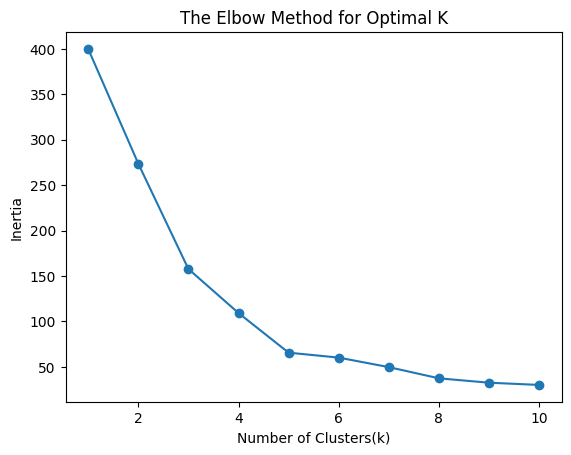

In [ ]:
inertia_values = []
for k in range(1,11):
  kmeans = KMeans(n_clusters=k,random_state=42)
  kmeans.fit(x_scaled)
  inertia_values.append(kmeans.inertia_)
print(inertia_values)
plt.figure()
plt.plot(range(1,11),inertia_values,marker='o')
plt.xlabel('Number of Clusters(k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method for Optimal K')
plt.show()

In [ ]:
Kmeans = KMeans(n_clusters=9,random_state=42)
clusters = Kmeans.fit_predict(x_scaled)
df['clusters'] = clusters
print(df.head())

   CustomerID  Gender  ...  Spending Score (1-100)  clusters
0           1    Male  ...                      39         8
1           2    Male  ...                      81         3
2           3  Female  ...                       6         4
3           4  Female  ...                      77         3
4           5  Female  ...                      40         8

[5 rows x 6 columns]


In [ ]:
print("Intertia:",Kmeans.inertia_)
sil_Score = silhouette_score(x_scaled,clusters)
print("Silhouette Score:",sil_Score)

Intertia: 32.495081199100916
Silhouette Score: 0.4566624374485964


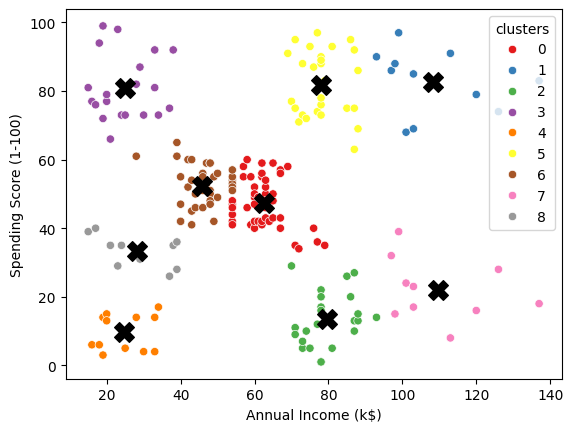

In [ ]:
plt.figure
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',hue='clusters',data=df,palette='Set1')
centroids = scaler.inverse_transform(Kmeans.cluster_centers_)
plt.scatter(centroids[:,0],centroids[:,1],marker='X',s=200,c='black',label='Centroids')